# Legal Amount Recognition

Reading the handwritten Arabic amount with the same CRNN architecture used for the digits. The model is not the interesting part here; the label representation is.

The dataset labels Arabic amounts as **sub-word fragments** rather than words, so ريال arrives as `['ر', 'يا', 'ل']`. That produces a 288-token vocabulary over roughly 7,200 augmented training samples, about 90 examples per class. This notebook tries three things about that:

| | Change | Outcome |
|:---|:---|:---|
| A | Spelling normalization, collapsing Arabic orthographic variants into canonical forms before building the vocabulary | 288 to 270 tokens; the model using it was not trained to completion |
| B | Character-level tokenization, treating each character as a class instead of each fragment | 53 classes, about 500 examples each; this is the model that was trained and reported |
| C | Dictionary post-processing, correcting decoded tokens by minimum edit distance | Made recognition far worse, and is reported below rather than dropped |

**Result: 9.02% character error rate, 430 of 600 amounts read exactly.** The error analysis at the end shows most of what remains is not misread handwriting.

Requires the detection notebook for the legal crops.

## 1. Imports & Setup

In [2]:
import sys, os, json, random
sys.path.insert(0, os.path.abspath('.'))

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

from utils import (
    TRAIN_LA, TEST_LA, ARTIFACTS,
    parse_legal_amounts,
    build_vocab, legal_summary, edit_distance,
    legal_text_to_digits,
)

# ── Albumentations (optional) ────────────────────────────────────────────────
try:
    import albumentations as A
    HAS_ALB = True
except ImportError:
    HAS_ALB = False
    print('albumentations not found — augmentation disabled.')

_AUG_TRANSFORMS = [
    A.Compose([A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=1.0, border_mode=0)]),
    A.Compose([A.Rotate(limit=10, p=1.0, border_mode=0)]),
    A.Compose([A.RandomScale(scale_limit=0.15, p=1.0)]),
] if HAS_ALB else []


def augment_pil(image: Image.Image) -> list:
    """Return the original PIL image + up to 3 augmented variants (4× total)."""
    variants = [image]
    arr = np.array(image)
    for t in _AUG_TRANSFORMS:
        aug_arr = t(image=arr)['image']
        variants.append(Image.fromarray(aug_arr))
    return variants


# ── Device ──────────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    DEVICE = 'cuda'
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'
print(f'Device: {DEVICE}')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
plt.rcParams['figure.dpi'] = 120

CROPS_DIR = ARTIFACTS / 'crops'
MODEL_DIR = ARTIFACTS / 'legal_model_improved'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# ── Shared Hyper-parameters ──────────────────────────────────────────────────
IMG_H    = 32
MIN_W    = 160
HIDDEN   = 256
N_LSTM   = 2
EPOCHS   = 120
BATCH    = 16
LR       = 1e-3
PATIENCE = 20
BLANK    = 0


Device: cuda


C:\Users\Admin\AppData\Local\Temp\ipykernel_9880\1645833641.py:32: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.Compose([A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=1.0, border_mode=0)]),


## 2. Load Raw Labels

In [3]:
train_labels_raw = parse_legal_amounts(TRAIN_LA)
test_labels_raw  = parse_legal_amounts(TEST_LA)

print(f'Train: {len(train_labels_raw)} samples')
print(f'Test : {len(test_labels_raw)} samples')

# Peek at a few raw labels
for fname, toks in list(train_labels_raw.items())[:3]:
    print(f'  {fname}: {toks}')

Train: 1799 samples
Test : 600 samples
  Lac00000.tif: ['ثمانيه', 'و', 'اربع', 'و', 'ن', 'أ', 'لف', 'و', 'ستمائ', 'ة', 'و', 'سته', 'و', 'عشر', 'و', 'ن', 'ر', 'يا', 'ل']
  Lac00001.tif: ['أ', 'لف', 'و', 'ثلاثمائ', 'ة', 'و', 'خمس', 'و', 'ن', 'ر', 'يا', 'ل', 'فقط', 'لا', 'غير']
  Lac00002.tif: ['فقط', 'أ', 'لف', 'و', 'خمسمائه', 'ر', 'يا', 'ل', 'لا', 'غير']


## 3. Tokenization Strategies

### 3A — Spelling normalization

The raw vocabulary contains **orthographic duplicates**: the same Arabic word written with different characters, so `مائة`, `مائه` and `مئة` all mean one hundred. A normalization map collapses each group into a canonical form before the vocabulary is built, covering the two main axes of variation, alef forms (`أ` / `إ` / `آ` to `ا`) and taa-marbuta against haa (`ه` against `ة`).

This shrinks the vocabulary and gives each surviving class more examples. Keep this map in mind: it reappears at the end of the notebook as the fix for the dominant remaining error, on a branch it was never applied to.

In [4]:
# ── Spelling Normalization Map ───────────────────────────────────────────────
# Maps variant Arabic spellings to a single canonical form.
# Covers two main orthographic variation axes:
#   (1) alef variants  (أ / إ / آ  →  ا)
#   (2) taa-marbuta   (ه  ←→  ة)
# plus a handful of word-specific colloquial vs. formal alternatives.

SPELLING_MAP = {
    # ── Hundreds ──────────────────────────────────────────────────────────
    'مائه'      : 'مائة',
    'مئة'       : 'مائة',
    'مئه'       : 'مائة',
    'مئتان'     : 'مائتان',
    'مئتين'     : 'مائتين',
    'مائتين'    : 'مائتان',
    'ثلاثمائه'  : 'ثلاثمائة',
    'ثلثمائة'   : 'ثلاثمائة',
    'ثلثمائه'   : 'ثلاثمائة',
    'اربعمائة'  : 'أربعمائة',
    'أربعمائه'  : 'أربعمائة',
    'اربعمائه'  : 'أربعمائة',
    'خمسمائه'   : 'خمسمائة',
    'خمسمئة'    : 'خمسمائة',
    'ستمائه'    : 'ستمائة',
    'ستمئة'     : 'ستمائة',
    'سبعمائه'   : 'سبعمائة',
    'ثمانمائه'  : 'ثمانمائة',
    'ثمانيمائة' : 'ثمانمائة',
    'ثمانيمائه' : 'ثمانمائة',
    'تسعمائه'   : 'تسعمائة',
    # ── Thousands ─────────────────────────────────────────────────────────
    'الف'       : 'ألف',
    'الفا'      : 'ألفا',
    'الفين'     : 'ألفين',
    'آلاف'      : 'ألاف',
    'آلافا'     : 'ألافا',
    # ── Units / tens – alef normalization ─────────────────────────────────
    'اربع'      : 'أربع',
    'اربعة'     : 'أربعة',
    'اربعون'    : 'أربعون',
    'اربعين'    : 'أربعين',
    'احدى'      : 'إحدى',
    'احد'       : 'أحد',
    # ── taa-marbuta harmonization ─────────────────────────────────────────
    'ثمانيه'    : 'ثمانية',
    'سته'       : 'ستة',
    'ثلاثه'     : 'ثلاثة',
    'خمسه'      : 'خمسة',
    'سبعه'      : 'سبعة',
    'تسعه'      : 'تسعة',
    'عشره'      : 'عشرة',
}


def normalize_token(tok):
    """Apply spelling normalization to a single sub-word token."""
    return SPELLING_MAP.get(tok, tok)


def normalize_sequence(token_list):
    """Normalize every token in a label sequence."""
    return [normalize_token(t) for t in token_list]


# Apply normalization
train_labels_wl = {k: normalize_sequence(v) for k, v in train_labels_raw.items()}
test_labels_wl  = {k: normalize_sequence(v) for k, v in test_labels_raw.items()}

# Build normalized vocabulary
all_wl_seqs = list(train_labels_wl.values()) + list(test_labels_wl.values())
wl_vocab, wl_t2i, wl_i2t = build_vocab(all_wl_seqs)

# Compare with raw vocab
raw_all = list(train_labels_raw.values()) + list(test_labels_raw.values())
raw_vocab, _, _ = build_vocab(raw_all)

print(f'Raw vocab size          : {len(raw_vocab)} tokens')
print(f'Normalized vocab size   : {len(wl_vocab)} tokens')
print(f'Tokens eliminated       : {len(raw_vocab) - len(wl_vocab)}')

Raw vocab size          : 288 tokens
Normalized vocab size   : 270 tokens
Tokens eliminated       : 18


### 3B — Character-Level Tokenization

Rather than treating each sub-word fragment as a class, treat each **character** as one. Arabic number words draw on a limited part of the alphabet, so the class count collapses and every class gains examples.

Note what the data actually yields against what the reference paper reports. The paper describes roughly 24 characters plus a space. This corpus produces **53 classes including the CTC blank, 52 distinct characters**, because the labels also carry Western and Arabic-Indic digits, punctuation such as `#`, `/` and `،`, and every alef and hamza variant kept separate.

That last part matters. The normalization map from 3A, which would merge those variants, is applied to the word-level vocabulary and not to this one.

In [5]:
def tokens_to_chars(token_list):
    """
    Convert a sub-word token list to a character sequence.
    Consecutive tokens are joined without a separator; a single space is
    inserted between tokens that represent distinct words so the decoder
    can recover word boundaries.

    Heuristic: a token is a 'word-starter' when the previous token is a
    complete word (length ≥ 2 and not a single Arabic letter suffix).
    For simplicity, we join all tokens with no space (the space character
    is never present in the raw annotations anyway).
    """
    joined = ''.join(token_list)   # concatenate all fragments
    return list(joined)            # split into individual characters


train_labels_cl = {k: tokens_to_chars(v) for k, v in train_labels_raw.items()}
test_labels_cl  = {k: tokens_to_chars(v) for k, v in test_labels_raw.items()}

# Build character vocabulary
all_cl_seqs = list(train_labels_cl.values()) + list(test_labels_cl.values())
cl_vocab, cl_t2i, cl_i2t = build_vocab(all_cl_seqs)

print(f'Character vocab size    : {len(cl_vocab)} tokens (incl. <blank>)')
print(f'Unique chars in data    : {len(cl_vocab) - 1}')
print(f'Characters: {sorted(cl_vocab[1:])}')

Character vocab size    : 53 tokens (incl. <blank>)
Unique chars in data    : 52
Characters: ['#', '/', '0', '1', '4', '6', '،', 'ء', 'آ', 'أ', 'إ', 'ئ', 'ا', 'ب', 'ة', 'ت', 'ث', 'ج', 'ح', 'خ', 'د', 'ر', 'س', 'ش', 'ص', 'ض', 'ط', 'ظ', 'ع', 'غ', 'ف', 'ق', 'ك', 'ل', 'م', 'ن', 'ه', 'و', 'ى', 'ي', 'ً', '٠', '١', '٢', '٣', '٤', '٥', '٦', '٧', '٨', '٩', '⁄']


### 3C — Vocabulary Summary

In [6]:
modes = [
    ('Baseline sub-word',          raw_vocab),
    ('Enhanced word-level (norm)', wl_vocab),
    ('Character-level',            cl_vocab),
]

header = '{:<30} {:>12} {:>26}'.format('Mode', 'Vocab size', 'Samples / class (approx)')
print(header)
print('-' * 70)
n_train = len(train_labels_raw)
avg_len = np.mean([len(v) for v in train_labels_raw.values()])
for name, vocab in modes:
    n_cls = len(vocab) - 1  # exclude blank
    spc   = n_train * avg_len / max(n_cls, 1)
    print('{:<30} {:>12} {:>26.1f}'.format(name, len(vocab), spc))

Mode                             Vocab size   Samples / class (approx)
----------------------------------------------------------------------
Baseline sub-word                       288                       90.5
Enhanced word-level (norm)              270                       96.5
Character-level                          53                      499.4


## 4. Dataset & DataLoader

A single `LegalDataset` class accepts a `label_dict` keyed by filename and a `tokenize_fn`
that maps the raw sub-word token list to whatever label representation is desired.

In [7]:
class LegalDataset(Dataset):
    def __init__(self, crops_dir, labels, t2i, img_h=32, min_w=160, augment=False):
        """
        labels  : dict  filename → list of label tokens (already tokenized)
        t2i     : dict  token → int index
        augment : bool  if True, expand each sample to 4 variants (original + 3 augmented)
        """
        self.t2i   = t2i
        self.img_h = img_h
        self.min_w = min_w
        self.samples = []   # list of (PIL.Image | Path, token_list)

        for img_path in sorted(crops_dir.glob('*.tif')):
            key = img_path.name
            if key in labels and len(labels[key]) > 0:
                if augment and HAS_ALB:
                    # Pre-load image and expand to 4 variants (original + 3 augmented)
                    img = Image.open(img_path).convert('L')
                    for variant in augment_pil(img):
                        self.samples.append((variant, labels[key]))
                else:
                    self.samples.append((img_path, labels[key]))

        print(f'Dataset: {len(self.samples)} samples from {crops_dir.parent.name}/{crops_dir.name} (augment={augment and HAS_ALB})')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        source, token_seq = self.samples[idx]
        if isinstance(source, Path):
            img = Image.open(source).convert('L')
        else:
            img = source if source.mode == 'L' else source.convert('L')

        w, h  = img.size
        new_w = max(self.min_w, int(w * self.img_h / h))
        img   = img.resize((new_w, self.img_h), Image.BILINEAR)
        # Flip horizontally so the CRNN time axis (left→right) matches
        # Arabic RTL reading order (right→left).
        img   = img.transpose(Image.FLIP_LEFT_RIGHT)
        img_t = T.ToTensor()(img)

        label = torch.tensor(
            [self.t2i[t] for t in token_seq if t in self.t2i],
            dtype=torch.long
        )
        return img_t, label


def make_collate(img_h):
    def collate_fn(batch):
        imgs, labels = zip(*batch)
        max_w  = max(img.shape[2] for img in imgs)
        padded = torch.ones(len(imgs), 1, img_h, max_w)
        for i, img in enumerate(imgs):
            padded[i, :, :, :img.shape[2]] = img
        label_lengths = torch.tensor([len(l) for l in labels], dtype=torch.long)
        labels_cat    = torch.cat(labels)
        input_lengths = torch.tensor([max_w // 4 for _ in imgs], dtype=torch.long)
        return padded, labels_cat, input_lengths, label_lengths
    return collate_fn


collate_fn = make_collate(IMG_H)


def make_loaders(crops_dir, train_labels, test_labels, t2i):
    # augment=True expands each training sample to 4 variants (original + 3 augmented)
    train_ds = LegalDataset(crops_dir / 'train' / 'legal', train_labels, t2i, IMG_H, MIN_W, augment=True)
    test_ds  = LegalDataset(crops_dir / 'test'  / 'legal', test_labels,  t2i, IMG_H, MIN_W)

    val_size   = int(0.1 * len(train_ds))
    train_size = len(train_ds) - val_size
    train_sub, val_sub = torch.utils.data.random_split(
        train_ds, [train_size, val_size],
        generator=torch.Generator().manual_seed(SEED)
    )

    train_loader = DataLoader(train_sub, batch_size=BATCH, shuffle=True,
                              collate_fn=collate_fn, num_workers=0, pin_memory=True)
    val_loader   = DataLoader(val_sub,   batch_size=BATCH, shuffle=False,
                              collate_fn=collate_fn, num_workers=0, pin_memory=True)
    test_loader  = DataLoader(test_ds,   batch_size=BATCH, shuffle=False,
                              collate_fn=collate_fn, num_workers=0, pin_memory=True)

    print(f'  → train {train_size} | val {val_size} | test {len(test_ds)}')
    return train_loader, val_loader, test_loader, train_ds, test_ds


In [8]:
print('── Enhanced word-level loaders ──')
wl_train_loader, wl_val_loader, wl_test_loader, wl_train_ds, wl_test_ds = \
    make_loaders(CROPS_DIR, train_labels_wl, test_labels_wl, wl_t2i)

print('── Character-level loaders ──')
cl_train_loader, cl_val_loader, cl_test_loader, cl_train_ds, cl_test_ds = \
    make_loaders(CROPS_DIR, train_labels_cl, test_labels_cl, cl_t2i)

── Enhanced word-level loaders ──
Dataset: 7192 samples from train/legal (augment=True)
Dataset: 600 samples from test/legal (augment=False)
  → train 6473 | val 719 | test 600
── Character-level loaders ──
Dataset: 7192 samples from train/legal (augment=True)
Dataset: 600 samples from test/legal (augment=False)
  → train 6473 | val 719 | test 600


## 5. CRNN Model

Same architecture as the baseline (7-block CNN backbone → 2-layer BiLSTM → CTC head),
but the output layer size is parameterised so the same class can serve both vocab sizes.

In [19]:
def conv_bn_relu(in_ch, out_ch):
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, 3, padding=1),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
    )


class CRNN(nn.Module):
    def __init__(self, n_classes, hidden=256, n_lstm=2):
        super().__init__()
        self.cnn = nn.Sequential(
            conv_bn_relu(1,   64),  nn.MaxPool2d(2, 2),
            conv_bn_relu(64,  128), nn.MaxPool2d(2, 2),
            conv_bn_relu(128, 256), conv_bn_relu(256, 256), nn.MaxPool2d((2, 1)),
            conv_bn_relu(256, 512), conv_bn_relu(512, 512), nn.MaxPool2d((2, 1)),
            conv_bn_relu(512, 512), nn.MaxPool2d((2, 1)),
        )
        self.lstm = nn.LSTM(
            input_size=512, hidden_size=hidden,
            num_layers=n_lstm, bidirectional=True,
            batch_first=False, dropout=0.2 if n_lstm > 1 else 0
        )
        self.fc = nn.Linear(hidden * 2, n_classes)

    def forward(self, x):
        x = self.cnn(x)           # (B, 512, 1, W//4)
        x = x.squeeze(2)          # (B, 512, T)
        x = x.permute(2, 0, 1)   # (T, B, 512)
        x, _ = self.lstm(x)       # (T, B, hidden*2)
        x = self.fc(x)            # (T, B, n_classes)
        return torch.log_softmax(x, dim=-1)


wl_model = CRNN(len(wl_vocab), hidden=HIDDEN, n_lstm=N_LSTM).to(DEVICE)
cl_model = CRNN(len(cl_vocab), hidden=HIDDEN, n_lstm=N_LSTM).to(DEVICE)

print(f'Word-level model parameters : {sum(p.numel() for p in wl_model.parameters() if p.requires_grad):,}')
print(f'Char-level model parameters : {sum(p.numel() for p in cl_model.parameters() if p.requires_grad):,}')

Word-level model parameters : 10,156,430
Char-level model parameters : 10,045,109


## 6. Training

A shared `run_epoch` / `train_model` function trains either model; we run both and compare.

In [17]:
def greedy_decode(log_probs, i2t, blank=BLANK):
    """CTC greedy decoder — collapses repeated tokens and removes blanks."""
    indices = log_probs.argmax(dim=-1).cpu().tolist()
    tokens, prev = [], None
    for idx in indices:
        if idx != prev:
            tokens.append(idx)
        prev = idx
    return [i2t[i] for i in tokens if i != blank]


def token_accuracy(refs, hyps):
    """1 - CER, expressed as a percentage."""
    total_N, total_ed = 0, 0
    for r, h in zip(refs, hyps):
        total_ed += edit_distance(r, h)
        total_N  += len(r)
    return max(0.0, (1 - total_ed / max(total_N, 1))) * 100


def run_epoch(loader, model, criterion, i2t, optimiser=None):
    training = optimiser is not None
    model.train() if training else model.eval()
    total_loss = 0
    refs, hyps = [], []

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for imgs, labels, in_lens, lbl_lens in loader:
            imgs      = imgs.to(DEVICE)
            log_probs = model(imgs)
            T_actual  = log_probs.size(0)
            in_lens   = torch.clamp(in_lens, max=T_actual)

            loss = criterion(
                log_probs, labels.to(DEVICE),
                in_lens.to(DEVICE), lbl_lens.to(DEVICE)
            )
            if training:
                optimiser.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                optimiser.step()

            total_loss += loss.item()

            offset = 0
            for i, llen in enumerate(lbl_lens.tolist()):
                ref = [i2t[idx] for idx in labels[offset:offset + llen].tolist()]
                hyp = greedy_decode(log_probs[:, i, :], i2t)
                refs.append(ref); hyps.append(hyp)
                offset += llen

    return total_loss / len(loader), token_accuracy(refs, hyps)


def train_model(model, i2t, train_loader, val_loader, save_path, tag):
    """Full training loop with early stopping; returns history dict."""
    criterion = nn.CTCLoss(blank=BLANK, reduction='mean', zero_infinity=True)
    optimiser = optim.Adam(model.parameters(), lr=LR)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimiser, mode='max', factor=0.5, patience=8, min_lr=1e-5
    )

    best_val_acc = -1
    patience_ctr = 0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc = run_epoch(train_loader, model, criterion, i2t, optimiser)
        vl_loss, vl_acc = run_epoch(val_loader,   model, criterion, i2t)
        scheduler.step(vl_acc)

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            patience_ctr = 0
            torch.save(model.state_dict(), save_path)
            flag = ' ✓'
        else:
            patience_ctr += 1
            flag = ''

        print(f'[{tag}] Ep {epoch:>3}/{EPOCHS} | '
              f'tr {tr_loss:.4f}/{tr_acc:.1f}% | '
              f'val {vl_loss:.4f}/{vl_acc:.1f}%{flag}', flush=True)

        if patience_ctr >= PATIENCE:
            print(f'Early stopping at epoch {epoch}.', flush=True)
            break

    print(f'[{tag}] Best val accuracy: {best_val_acc:.2f}%', flush=True)
    return history, best_val_acc

In [33]:
# ── Train enhanced word-level model ─────────────────────────────────────────
wl_history, wl_best_val = train_model(
    wl_model, wl_i2t,
    wl_train_loader, wl_val_loader,
    MODEL_DIR / 'best_wl.pt',
    tag='WL'  
)

[WL] Ep   1/120 | tr 3.0094/15.3% | val 2.2712/31.5% ✓
[WL] Ep   2/120 | tr 2.1664/32.8% | val 2.4030/31.1%
[WL] Ep   3/120 | tr 1.9737/36.7% | val 1.9245/42.5% ✓


KeyboardInterrupt: 

In [9]:
# we already test it without augmentation and it was around 80% token accuracy, so we expect a significant boost from the augmented training set. The training time will be longer due to the increased dataset size, but it should be manageable on a GPU.

In [ ]:
# Train character-level model
cl_history, cl_best_val = train_model(
    cl_model, cl_i2t,
    cl_train_loader, cl_val_loader,
    MODEL_DIR / 'best_cl.pt',
    tag='CL'
)

[CL] Ep   1/120 | tr 0.1249/97.0% | val 0.1108/97.0% ✓
[CL] Ep   2/120 | tr 0.0732/97.7% | val 0.1219/96.9%
[CL] Ep   3/120 | tr 0.0578/98.1% | val 0.1220/96.8%
[CL] Ep   4/120 | tr 0.0447/98.4% | val 0.4533/90.7%
[CL] Ep   5/120 | tr 0.0410/98.5% | val 0.2007/94.4%
[CL] Ep   6/120 | tr 0.0712/97.5% | val 0.1269/97.0%
[CL] Ep   7/120 | tr 0.0426/98.4% | val 0.1202/97.2% ✓
[CL] Ep   8/120 | tr 0.0376/98.6% | val 0.0983/97.7% ✓
[CL] Ep   9/120 | tr 0.0360/98.7% | val 0.1115/97.3%
[CL] Ep  10/120 | tr 0.0326/98.8% | val 0.1197/97.0%
[CL] Ep  11/120 | tr 0.0272/99.0% | val 0.1230/97.3%
[CL] Ep  12/120 | tr 0.0398/98.5% | val 0.1258/96.6%
[CL] Ep  13/120 | tr 0.0551/98.0% | val 0.2217/94.4%
[CL] Ep  14/120 | tr 0.0379/98.7% | val 0.2736/93.7%
[CL] Ep  15/120 | tr 0.0248/99.1% | val 0.1136/97.5%
[CL] Ep  16/120 | tr 0.0221/99.2% | val 0.0974/97.8% ✓
[CL] Ep  17/120 | tr 0.0182/99.4% | val 0.1199/97.3%
[CL] Ep  18/120 | tr 0.0321/98.9% | val 0.1370/97.0%
[CL] Ep  19/120 | tr 0.0244/99.1% | va

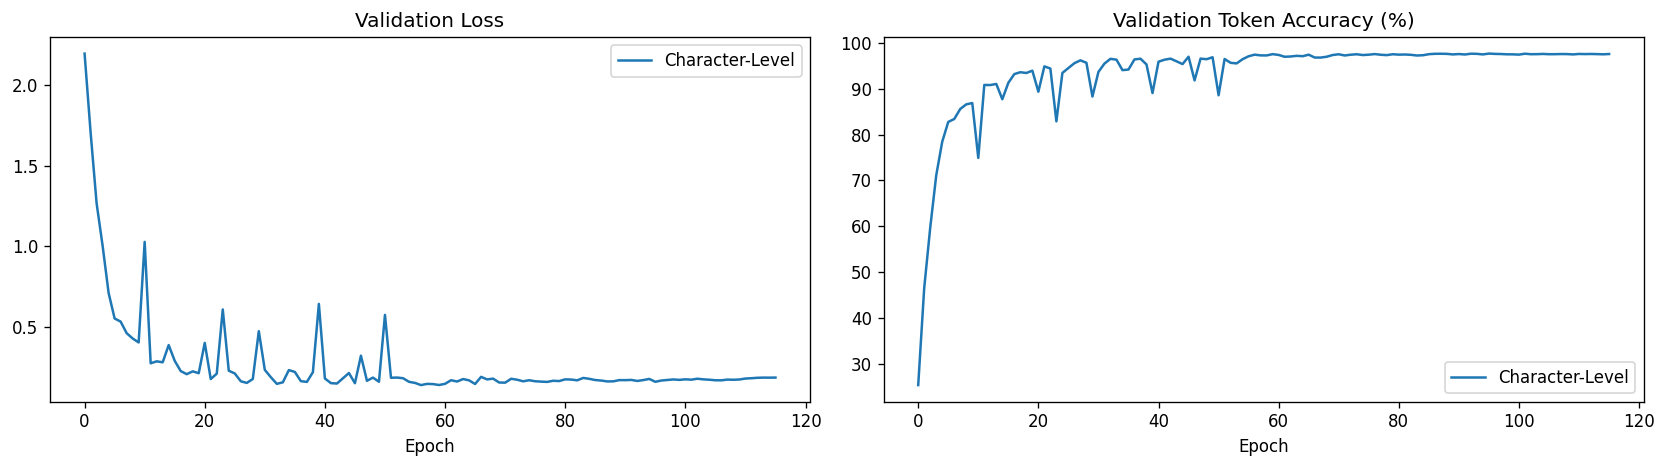

Best val acc — Char-level: 97.64%


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, key, title in [
    (axes[0], 'val_loss', 'Validation Loss'),
    (axes[1], 'val_acc',  'Validation Token Accuracy (%)'),
]:
    ax.plot(cl_history[key], label='Character-Level')
    ax.set_xlabel('Epoch')
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.savefig(ARTIFACTS / 'partC_improved_training_curves.png', bbox_inches='tight')
plt.show()

print(f'Best val acc — Char-level: {cl_best_val:.2f}%')


## 7. Post-Processing: Dictionary Matching & Linear Search

Even a well-trained CRNN can produce out-of-vocabulary tokens or accidentally merge two adjacent
words into one.  We add a two-stage post-processing layer:

**Stage 1 – Minimum Edit Distance (MED) correction.**  
For every decoded token that is *not* in the training dictionary we find the closest valid word
and substitute it.  Ties are resolved in Stage 3 (Mutual Enhancement).

**Stage 2 – Linear Search for merged words.**  
If no close single-word match exists, we try *all* possible split-points of the unknown token,
looking for a pair `(left, right)` that are both in the dictionary.  The split with the lowest
combined edit distance is preferred.

In [ ]:
#  Build dictionary from training labels 
# We use normalized word-level tokens as the canonical dictionary.
DICTIONARY = set()
for token_list in train_labels_wl.values():
    DICTIONARY.update(token_list)

# Remove the CTC blank placeholder if accidentally included
DICTIONARY.discard('<blank>')

DICT_LIST = sorted(DICTIONARY)  # sorted list for deterministic tie-breaking

print(f'Dictionary size: {len(DICTIONARY)} unique tokens')
print(f'Sample entries : {DICT_LIST[:10]}')

Dictionary size: 223 unique tokens
Sample entries : ['#١٥٠٠٠٠#', '64/100', 'آ', 'أ', 'أالف', 'أثن', 'أثنا', 'أحد', 'أحدا', 'أحدى']


In [ ]:
def med_correct(token, dictionary, max_dist=2):
    """
    Return a list of (distance, candidate) pairs from `dictionary` that
    are within `max_dist` of `token`.  Returns [(0, token)] if the token
    is already in the dictionary.
    """
    if token in dictionary:
        return [(0, token)]

    token_chars = list(token)
    candidates = []
    for word in dictionary:
        d = edit_distance(token_chars, list(word))
        if d <= max_dist:
            candidates.append((d, word))

    candidates.sort(key=lambda x: x[0])
    return candidates  # empty list ↔ no close match found


def linear_split_search(token, dictionary):
    """
    Try every split of `token` into two non-empty sub-strings.
    Return the (left, right) pair where both halves have minimum combined
    edit distance to their nearest dictionary words.
    Returns None if no split yields two in-vocabulary words within distance 1 each.
    """
    best_pair  = None
    best_score = float('inf')

    for split in range(1, len(token)):
        left  = token[:split]
        right = token[split:]

        left_cands  = med_correct(left,  dictionary, max_dist=1)
        right_cands = med_correct(right, dictionary, max_dist=1)

        if left_cands and right_cands:
            score = left_cands[0][0] + right_cands[0][0]
            if score < best_score:
                best_score = score
                best_pair  = (left_cands[0][1], right_cands[0][1])

    return best_pair


def postprocess_sequence(tokens, dictionary, max_med_dist=2):
    """
    Apply MED + linear-split post-processing to a decoded token sequence.

    Returns
    -------
    corrected_tokens : list[str]
        Post-processed token sequence (may be longer if splits occurred).
    candidates_map   : dict  token_idx → list[(dist, candidate)]
        For each position that needed correction, the list of MED candidates
        (used by Mutual Enhancement to break ties).
    """
    corrected      = []
    candidates_map = {}  # position in output → MED candidates list

    for tok in tokens:
        if tok in dictionary:
            corrected.append(tok)
            continue

        cands = med_correct(tok, dictionary, max_dist=max_med_dist)

        if cands:
            # Record position and candidates before choosing the top one
            pos = len(corrected)
            candidates_map[pos] = cands
            corrected.append(cands[0][1])  # placeholder (tie-breaker may override)

        else:
            # Try splitting the unknown token into two valid words
            pair = linear_split_search(tok, dictionary)
            if pair:
                corrected.extend(list(pair))
            else:
                corrected.append(tok)  # keep as-is (unresolvable)

    return corrected, candidates_map


# Quick sanity check 
test_tok = 'خمسمائه'  # variant not in dictionary (if normalization is applied)
print(f'MED candidates for "{test_tok}":')
for d, w in med_correct(test_tok, DICTIONARY):
    print(f'  distance={d}  word={w}')

MED candidates for "خمسمائه":
  distance=1  word=خمسمائ
  distance=1  word=خمسائه
  distance=1  word=خمسمائة
  distance=2  word=نمثمائه
  distance=2  word=خمسلمائ
  distance=2  word=خمسمئ


In [20]:
def get_raw_predictions(model, test_loader, i2t, model_tag):
    """Run the model on the test set and collect raw decoded predictions."""
    model.load_state_dict(torch.load(
        MODEL_DIR / f'best_{model_tag}.pt',
        map_location=DEVICE
    ))
    model.eval()

    all_refs, all_hyps = [], []

    with torch.no_grad():
        for imgs, labels, in_lens, lbl_lens in tqdm(test_loader, desc='Test eval'):
            imgs      = imgs.to(DEVICE)
            log_probs = model(imgs)
            T_actual  = log_probs.size(0)
            in_lens   = torch.clamp(in_lens, max=T_actual)

            offset = 0
            for i, llen in enumerate(lbl_lens.tolist()):
                ref = [i2t[idx] for idx in labels[offset:offset + llen].tolist()]
                hyp = greedy_decode(log_probs[:, i, :], i2t)
                all_refs.append(ref)
                all_hyps.append(hyp)
                offset += llen

    return all_refs, all_hyps


# ── Get raw predictions from character-level model ───────────────────────────
print('── Character-level model ──')
cl_refs, cl_hyps_raw = get_raw_predictions(cl_model, cl_test_loader, cl_i2t, 'cl')


── Character-level model ──


Test eval: 100%|██████████| 38/38 [00:04<00:00,  7.65it/s]


In [21]:
def apply_postprocessing(hyps_raw, dictionary):
    """
    Apply dictionary-based post-processing to a list of decoded sequences.

    For the character-level model the 'tokens' are individual characters;
    we first join them into a string and split on whitespace to recover
    word-level tokens before applying MED.
    """
    is_char_level = all(len(t) == 1 for hyp in hyps_raw[:5] for t in hyp if t)

    corrected_hyps = []
    all_cand_maps  = []

    for hyp in hyps_raw:
        if is_char_level:
            # join characters back into the full Arabic string, then
            # reconstruct word tokens by lexical matching against the dictionary
            joined = ''.join(hyp)
            # naive split: try dictionary words greedily from left to right
            words = greedy_word_segment(joined, dictionary)
        else:
            words = hyp

        corrected, cmap = postprocess_sequence(words, dictionary)
        corrected_hyps.append(corrected)
        all_cand_maps.append(cmap)

    return corrected_hyps, all_cand_maps


def greedy_word_segment(text, dictionary):
    """
    Greedy longest-match word segmentation.
    Scans `text` left-to-right, greedily consuming the longest prefix that
    matches a dictionary word.
    """
    words   = []
    i       = 0
    max_len = max((len(w) for w in dictionary), default=1)

    while i < len(text):
        best_match = None
        for length in range(min(max_len, len(text) - i), 0, -1):
            candidate = text[i:i + length]
            if candidate in dictionary:
                best_match = candidate
                break
        if best_match:
            words.append(best_match)
            i += len(best_match)
        else:
            # Single character — keep as unknown fragment
            words.append(text[i])
            i += 1

    return words


print('Applying post-processing to character-level predictions...')
cl_hyps_pp, cl_cand_maps = apply_postprocessing(cl_hyps_raw, DICTIONARY)


Applying post-processing to character-level predictions...


## 8. Evaluation & Comparison

Two configurations are evaluated below: the character-level model's raw CTC output, and the same output after dictionary post-processing.

The word-level model was not trained to completion. Its run was interrupted after three epochs, visible in the training output above, so the word-level rows are absent from the comparison and improvement A is measured only by its effect on vocabulary size, not by any recognition result.

In [22]:
def evaluate(refs, hyps, label):
    m = legal_summary(refs, hyps)
    print(f'{label:<52}  CER={m["CER"]:5.2f}%  WER={m["WER"]:5.2f}%')
    return m


results = {}
header = f'{"Configuration":<52}  {"CER":>8}  {"WER":>8}'
print(header)
print('-' * 74)

results['cl_raw'] = evaluate(cl_refs, cl_hyps_raw, '1. Char-level  raw')
results['cl_pp']  = evaluate(cl_refs, cl_hyps_pp,  '2. Char-level  + post-processing')


Configuration                                              CER       WER
--------------------------------------------------------------------------
1. Char-level  raw                                    CER= 9.02%  WER=75.83%
2. Char-level  + post-processing                      CER=80.49%  WER=81.00%


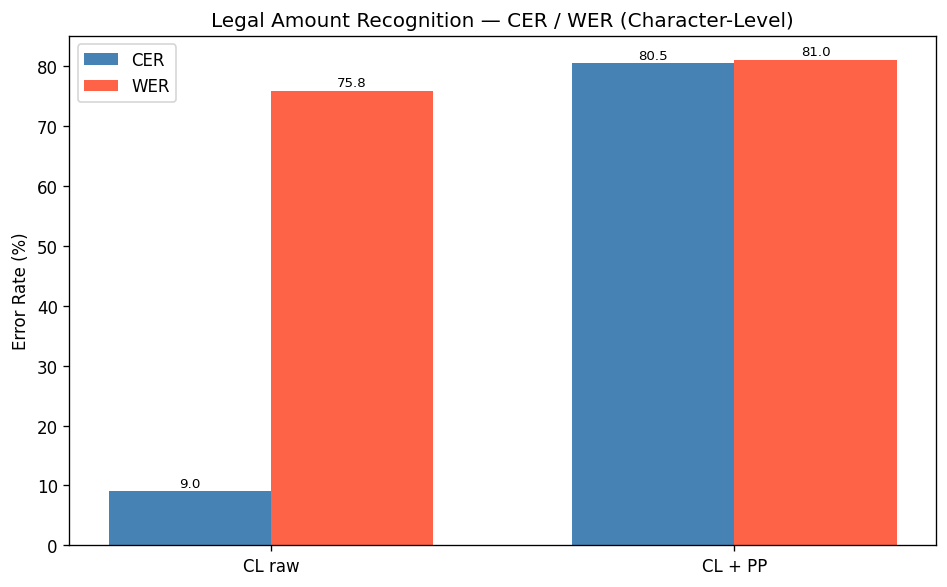

In [23]:
labels   = ['CL raw', 'CL + PP']
cer_vals = [results[k]['CER'] for k in ('cl_raw', 'cl_pp')]
wer_vals = [results[k]['WER'] for k in ('cl_raw', 'cl_pp')]

x     = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars_cer = ax.bar(x - width/2, cer_vals, width, label='CER', color='steelblue')
bars_wer = ax.bar(x + width/2, wer_vals, width, label='WER', color='tomato')

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Error Rate (%)')
ax.set_title('Legal Amount Recognition — CER / WER (Character-Level)')
ax.legend()

for bar in (*bars_cer, *bars_wer):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(ARTIFACTS / 'partC_improved_comparison.png', bbox_inches='tight')
plt.show()


## 10. Error Analysis

430 of 600 amounts are read exactly. The substitution table below is where the remaining error actually lives, and it is worth reading carefully.

**Almost none of it is misread handwriting.** The ten most frequent character substitutions are dominated by orthographic variants of the same letter:

| Reference | Predicted | Count | |
|:---|:---|---:|:---|
| ا | أ | 197 | alef variant |
| ه | ة | 164 | haa / taa-marbuta |
| ا | آ | 80 | alef variant |
| ة | ه | 55 | taa-marbuta / haa |
| أ | ا | 14 | alef variant |
| أ | آ | 13 | alef variant |
| إ | ا | 6 | alef variant |
| ي | و | 7 | genuine confusion |
| ا | ف | 5 | genuine confusion |
| ن | ث | 4 | genuine confusion |

**529 of these 545 substitutions, 97%, are alef or taa-marbuta variants.** In Arabic handwriting these forms are routinely written interchangeably, and the dataset's own labels are inconsistent about them, which is exactly why the spelling normalization map in section 3A exists.

That map was applied when building the word-level vocabulary. It was never applied to the character-level vocabulary, which is the model that was actually trained and scored. So the reported 9.02% CER counts a large volume of variant spellings as errors, and the fix for it was already written in this notebook and pointed at the wrong branch. Normalizing the character vocabulary, or normalizing both sides before scoring, should collapse most of the remaining error.

**The post-processing result.** Dictionary correction raised CER from 9.02% to 80.49%. The summary cell reports this as a "gain" of -71.47%, which is the sign convention rather than an improvement: the layer made recognition roughly nine times worse and the raw CTC output is what the project reports.

The reason is visible in the worst predictions above. CTC errors here are frequently *segmentation* errors, where a word arrives split or merged, rather than spelling errors. Nearest-dictionary-word matching cannot detect that, so it confidently replaces a fragment with a complete but unrelated word and turns a partially correct output into a wholly wrong one. A correction layer needs a confidence threshold and the ability to decline.

**One number not to lean on.** CER of 9.02% sits alongside a WER of 75.83%, which is difficult to reconcile with 430 of 600 sequences being exactly right. `legal_summary` computes WER by re-joining tokens and splitting on whitespace, so it is measuring word segmentation at least as much as recognition for a character-level model that has to emit its own spaces. The CER figure and the exact-match count are the trustworthy ones here.

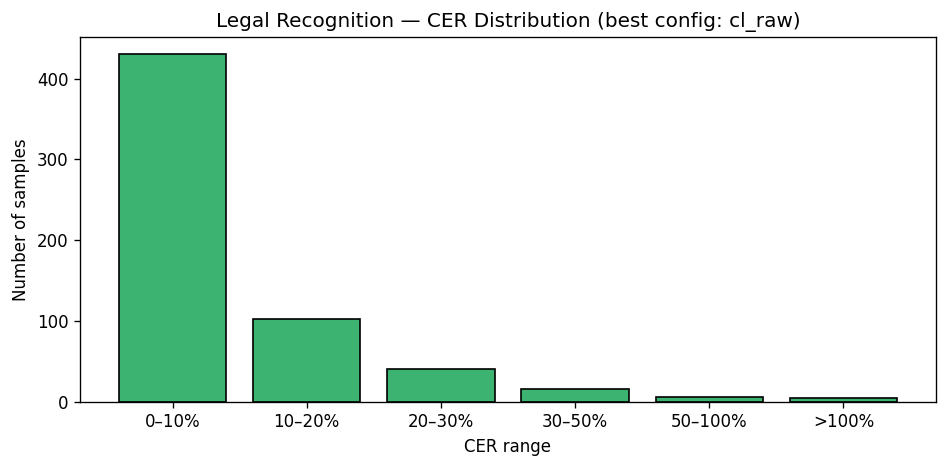

Perfect predictions (CER=0): 430 / 600

── Best predictions ──
  CER=0.00 | ref: عشرةآلافريالفقطلاغير | pred: عشرةآلافريالفقطلاغير
  CER=0.00 | ref: خمسةآلافرياللاغير | pred: خمسةآلافرياللاغير
  CER=0.00 | ref: فقطألفرياللاغير | pred: فقطألفرياللاغير
  CER=0.00 | ref: فقطأربعمائةوخمسونرياللاغير | pred: فقطأربعمائةوخمسونرياللاغير
  CER=0.00 | ref: فقطألفانوثمانمائةرياللاغير | pred: فقطألفانوثمانمائةرياللاغير

── Worst predictions ──
  CER=1.07 | ref: اثناعشرالفريال | pred: أحناىعشرألفريالونرياللاغير
  CER=1.17 | ref: اربعونالفرياللاغير | pred: أربعنآلافومئتئهثونريالوخمسونلطلاغير
  CER=1.40 | ref: الفريالفقط | pred: ألفريالخماوون٠هلولله
  CER=1.57 | ref: الفريال | pred: سقطةآلافرياللاغير
  CER=1.60 | ref: ألفريالفقط | pred: ألفريالاوخمسونارما٥ريال


In [24]:
# ── Per-sample CER distribution for the best configuration ──────────────────
best_key = min(results, key=lambda k: results[k]['CER'])
best_label_map = {
    'cl_raw': (cl_refs, cl_hyps_raw),
    'cl_pp' : (cl_refs, cl_hyps_pp),
}
best_refs, best_hyps = best_label_map[best_key]

per_sample = [
    {'cer': edit_distance(r, h) / max(len(r), 1), 'ref': r, 'hyp': h}
    for r, h in zip(best_refs, best_hyps)
]

cer_vals_ps = [s['cer'] for s in per_sample]
bins       = [0, 0.1, 0.2, 0.3, 0.5, 1.0, float('inf')]
bin_labels = ['0–10%', '10–20%', '20–30%', '30–50%', '50–100%', '>100%']
counts     = [sum(b1 <= c < b2 for c in cer_vals_ps) for b1, b2 in zip(bins[:-1], bins[1:])]

plt.figure(figsize=(8, 4))
plt.bar(bin_labels, counts, color='mediumseagreen', edgecolor='black')
plt.xlabel('CER range')
plt.ylabel('Number of samples')
plt.title(f'Legal Recognition — CER Distribution (best config: {best_key})')
plt.tight_layout()
plt.savefig(ARTIFACTS / 'partC_improved_cer_dist.png', bbox_inches='tight')
plt.show()

print(f'Perfect predictions (CER=0): {counts[0]} / {len(cer_vals_ps)}')

sorted_samples = sorted(per_sample, key=lambda x: x['cer'])
print('\n── Best predictions ──')
for s in sorted_samples[:5]:
    print(f"  CER={s['cer']:.2f} | ref: {''.join(s['ref'])} | pred: {''.join(s['hyp'])}")
print('\n── Worst predictions ──')
for s in sorted_samples[-5:]:
    print(f"  CER={s['cer']:.2f} | ref: {''.join(s['ref'])} | pred: {''.join(s['hyp'])}")


In [25]:
from collections import Counter


def substitution_pairs(ref, hyp):
    n, m = len(ref), len(hyp)
    dp = [[(0, '')] * (m + 1) for _ in range(n + 1)]
    for i in range(n + 1): dp[i][0] = (i, 'D')
    for j in range(m + 1): dp[0][j] = (j, 'I')
    dp[0][0] = (0, '')
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            if ref[i-1] == hyp[j-1]:
                dp[i][j] = (dp[i-1][j-1][0], 'M')
            else:
                best = min(
                    (dp[i-1][j][0] + 1, 'D'),
                    (dp[i][j-1][0] + 1, 'I'),
                    (dp[i-1][j-1][0] + 1, 'S'),
                )
                dp[i][j] = best
    pairs = []
    i, j = n, m
    while i > 0 or j > 0:
        _, op = dp[i][j]
        if op == 'S':   pairs.append((ref[i-1], hyp[j-1])); i -= 1; j -= 1
        elif op == 'D': i -= 1
        elif op == 'I': j -= 1
        else:           i -= 1; j -= 1
    return pairs


sub_counter = Counter()
for r, h in zip(best_refs, best_hyps):
    sub_counter.update(substitution_pairs(r, h))

print(f'Top 10 substitutions (ref → pred) for best config [{best_key}]:')
for (rt, ht), cnt in sub_counter.most_common(10):
    print(f'  "{rt}"  →  "{ht}"   ({cnt}×)')

Top 10 substitutions (ref → pred) for best config [cl_raw]:
  "ا"  →  "أ"   (197×)
  "ه"  →  "ة"   (164×)
  "ا"  →  "آ"   (80×)
  "ة"  →  "ه"   (55×)
  "أ"  →  "ا"   (14×)
  "أ"  →  "آ"   (13×)
  "ي"  →  "و"   (7×)
  "إ"  →  "ا"   (6×)
  "ا"  →  "ف"   (5×)
  "ن"  →  "ث"   (4×)


## 11. Save Results

In [26]:
# Save the best-configuration predictions (used as input to Part D)
is_char_level = True  # CL-only run


def _chars_to_words(chars):
    """Join individual characters and re-segment into word tokens."""
    return greedy_word_segment(''.join(chars), DICTIONARY)


predictions_out = []
for (source, _), ref, hyp in zip(cl_test_ds.samples, best_refs, best_hyps):
    fname = source.name if isinstance(source, Path) else getattr(source, 'filename', str(source))
    stem  = fname[1:].replace('.tif', '')

    ref_words = test_labels_wl.get(fname) or _chars_to_words(ref)
    hyp_words = _chars_to_words(hyp)
    ref_str = ' '.join(ref_words)
    hyp_str = ' '.join(hyp_words)

    predictions_out.append({
        'file'      : fname,
        'stem'      : stem,
        'reference' : ref_str,
        'predicted' : hyp_str,
        'config'    : best_key,
    })

with open(ARTIFACTS / 'partC_improved_predictions.json', 'w', encoding='utf-8') as f:
    json.dump(predictions_out, f, indent=2, ensure_ascii=False)

with open(ARTIFACTS / 'partC_improved_metrics.json', 'w') as f:
    json.dump(results, f, indent=2)

print(f'Saved {len(predictions_out)} predictions  (config: {best_key})')
print('Files written:')
print('  artifacts/partC_improved_predictions.json')
print('  artifacts/partC_improved_metrics.json')
print('  artifacts/partC_improved_training_curves.png')
print('  artifacts/partC_improved_comparison.png')
print('  artifacts/partC_improved_cer_dist.png')


Saved 600 predictions  (config: cl_raw)
Files written:
  artifacts/partC_improved_predictions.json
  artifacts/partC_improved_metrics.json
  artifacts/partC_improved_training_curves.png
  artifacts/partC_improved_comparison.png
  artifacts/partC_improved_cer_dist.png


## 12. Summary

Reported result: **9.02% character error rate, 430 of 600 amounts read exactly**, from the character-level model on raw CTC output.

Three things worth carrying out of this notebook.

**The representation change did the work, not the architecture.** The CRNN is identical to the one used for digits. Moving from 288 sub-word classes at about 90 examples each to 53 character classes at about 500 each is what took character error rate from 50.5% to 9.02%, a 5.6-fold reduction.

**The post-processing failed and is reported anyway.** Dictionary correction by minimum edit distance took CER from 9.02% to 80.49%. Section D below labels that a "gain" of -71.47%; read the sign carefully.

**The largest remaining error source is fixable and already has a fix in this notebook.** 97% of the top character substitutions are alef and taa-marbuta variants, which the section 3A normalization map exists to collapse. That map was applied to the word-level vocabulary, which was never trained, and not to the character-level one, which was.

In [28]:
print('═' * 60)
print('═' * 60)
print()
print('A. Vocabulary sizes')
print(f'   Baseline sub-word  : {len(raw_vocab)} tokens')
print(f'   Character-level    : {len(cl_vocab)} tokens  (~24 Arabic chars)')
print()
print('B. Model training (best validation accuracy)')
print()
print('C. Test-set evaluation')
col_w = 52
print(f"   {'Configuration':<{col_w}} {'CER':>6}  {'WER':>6}")
print('   ' + '-' * (col_w + 16))
config_labels = {
    'cl_raw': 'Char-level  (raw CTC)',
    'cl_pp' : 'Char-level  + dictionary post-processing',
}
for key, lbl in config_labels.items():
    m   = results[key]
    mrk = '  ← best' if key == best_key else ''
    print(f"   {lbl:<{col_w}} {m['CER']:>5.2f}%  {m['WER']:>5.2f}%{mrk}")
print()
print('D. Post-processing gain')
delta_cer = results['cl_raw']['CER'] - results['cl_pp']['CER']
delta_wer = results['cl_raw']['WER'] - results['cl_pp']['WER']
print(f'   CER reduced by {delta_cer:+.2f}%')
print(f'   WER reduced by {delta_wer:+.2f}%')
print()
print('═' * 60)


════════════════════════════════════════════════════════════
════════════════════════════════════════════════════════════

A. Vocabulary sizes
   Baseline sub-word  : 288 tokens
   Character-level    : 53 tokens  (~24 Arabic chars)

B. Model training (best validation accuracy)

C. Test-set evaluation
   Configuration                                           CER     WER
   --------------------------------------------------------------------
   Char-level  (raw CTC)                                 9.02%  75.83%  ← best
   Char-level  + dictionary post-processing             80.49%  81.00%

D. Post-processing gain
   CER reduced by -71.47%
   WER reduced by -5.17%

════════════════════════════════════════════════════════════
